# <center>Блок 6. Математика в ML. Часть II<center>
## <center>MATH&ML-10. Кластеризация и техники понижения размерности. Часть I<center>
### <center>1.Введение<center>
### <center>2.K-means<center>
#### Mini-Bath K-means
#### K-Means ++
### <center>3.EM-алгоритм<center>
### <center>4.K-Means и EM-алгоритм: практика<center>

In [46]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture

In [21]:
data = pd.read_csv('C:\\IDE\\data\\Block_6\\snsdata.csv')
data.head()

,gradyear,gender,age,friends,basketball,football,soccer,softball,volleyball,swimming,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,2006,M,18.982,7,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2006,F,18.801,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
2,2006,M,18.335,69,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,2006,F,18.875,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2006,NaN,18.995,10,0,0,0,0,0,0,...,0,0,2,0,0,0,0,0,1,1


In [22]:
# Задание 4.1

data = data.drop(['gradyear', 'gender', 'age', 'friends'], axis=1)
data.shape

(30000, 36)

In [23]:
# Задание 4.2
X = data.values
scaler = StandardScaler()
scaler.fit(X)
X_norm = scaler.transform(X)

print(np.round(X_norm[0][0],2))

-0.33


In [24]:
# Задание 4.3

kmeans = KMeans(n_clusters=9, random_state=42)
kmeans.fit(X_norm)
print(round(kmeans.inertia_,2))

856276.7


In [27]:
# Задание 4.4

cluster_sizes = np.bincount(kmeans.labels_)
print('Максимальный кластер: ',np.max(cluster_sizes))
print('Минимальный кластер: ', np.min(cluster_sizes))

Максимальный кластер:  19599
Минимальный кластер:  1


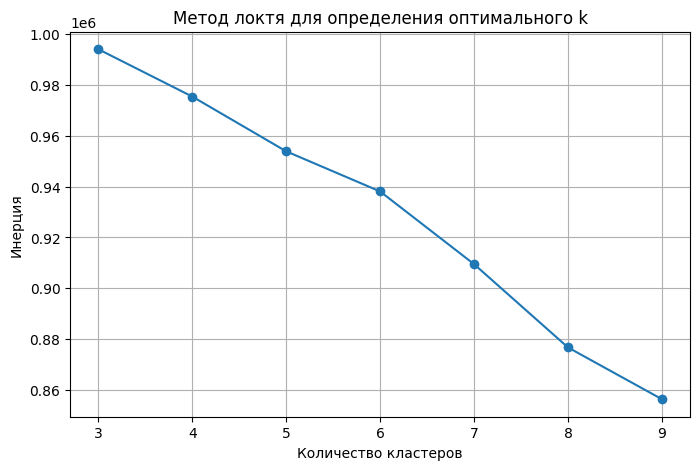

In [ ]:
# Задание 4.5-1

def get_inertia(cluster_num, X_norm):
    kmeans = KMeans(n_clusters=cluster_num, random_state=42)
    kmeans.fit(X_norm)
    inertia = kmeans.inertia_
    return inertia

res = [get_inertia(i, X_norm) for i in range(3, 10)]

plt.figure(figsize=(8, 5))
plt.plot(range(3, 10), res, marker='o')
plt.title('Метод локтя для определения оптимального k')
plt.xlabel('Количество кластеров')
plt.ylabel('Инерция')
plt.grid(True)
plt.show()

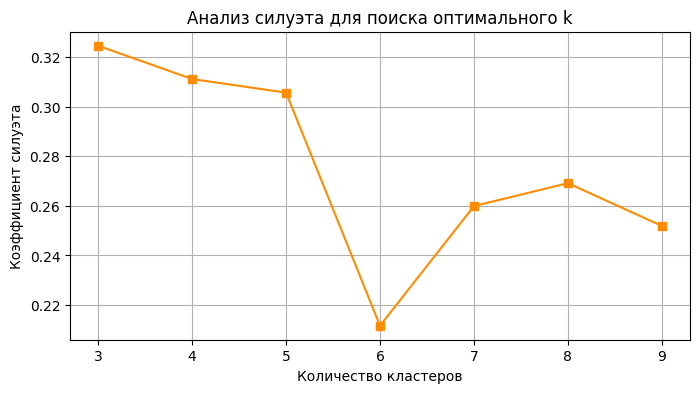

In [33]:
# Задание 4.5-2

def get_silhouette(cluster_num, X_norm):
    kmeans = KMeans(n_clusters=cluster_num, random_state=42)
    kmeans.fit(X_norm)
    silhouette = silhouette_score(X_norm, kmeans.labels_)
    return silhouette

silhouette = []
for cluster_num in range(3,10):
    silhouette.append(get_silhouette(cluster_num, X_norm))
    
plt.figure(figsize=(8, 4))
plt.plot(range(3, 10), silhouette, marker='s', color='darkorange')
plt.title('Анализ силуэта для поиска оптимального k')
plt.xlabel('Количество кластеров')
plt.ylabel('Коэффициент силуэта')
plt.grid(True)
plt.show()

In [ ]:
# Задание 4.6

import pandas as pd

# Шаг 1. Переводим нормализованные данные обратно в DataFrame с именами столбцов
X_norm_df = pd.DataFrame(X_norm, columns=data.columns)

# Шаг 2. Добавляем столбец с метками кластеров
X_norm_df['cluster'] = kmeans.labels_

# Сюда будем сохранять множества топ-10 слов для каждого кластера
top_keywords_by_cluster = []

print("--- КЛЮЧЕВЫЕ СЛОВА (ТОП-10) ДЛЯ КАЖДОГО КЛАСТЕРА ---")

# Шаг 3. Группируем по кластерам
for cluster_id, group in X_norm_df.groupby('cluster'):
    # Исключаем колонку 'cluster', считаем среднее, сортируем по убыванию и берем топ-10
    cluster_means = group.drop(columns='cluster').mean()
    top_10_words = cluster_means.sort_values(ascending=False).head(10).index.tolist()
    
    # Печатаем результат для текущего кластера
    print(f"Кластер №{cluster_id}: {top_10_words}")
    
    # Сохраняем как множество для последующего поиска общих слов
    top_keywords_by_cluster.append(set(top_10_words))

print("\n--- ПОИСК ОБЩИХ СЛОВ ---")

# Шаг 4. Находим пересечение множеств ключевых слов
common_words = set.intersection(*top_keywords_by_cluster)

if len(common_words) > 0:
    print(f"Ключевые слова, характерные для каждого кластера: {common_words}")
else:
    print("Общих ключевых слов среди топ-10 во всех кластерах не обнаружено (пустое множество).")


--- КЛЮЧЕВЫЕ СЛОВА (ТОП-10) ДЛЯ КАЖДОГО КЛАСТЕРА ---
Кластер №0: ['marching', 'blonde', 'tennis', 'band', 'bible', 'jesus', 'death', 'soccer', 'sexy', 'drunk']
Кластер №1: ['kissed', 'drugs', 'hair', 'sex', 'drunk', 'die', 'clothes', 'music', 'rock', 'death']
Кластер №2: ['shopping', 'cute', 'mall', 'church', 'hollister', 'basketball', 'football', 'dance', 'abercrombie', 'clothes']

--- ПОИСК ОБЩИХ СЛОВ ---
Общих ключевых слов среди топ-10 во всех кластерах не обнаружено (пустое множество).


In [47]:
# Задание 4.7

gauss_model = GaussianMixture(n_components=3, random_state=42)
gauss_model.fit(X_norm)
labels = gauss_model.predict(X_norm)
proba = gauss_model.predict_proba(X_norm)

cluster_sizes = np.bincount(labels)
print('Максимальный кластер: ',np.max(cluster_sizes))
print('Минимальный кластер: ', np.min(cluster_sizes))

Максимальный кластер:  20670
Минимальный кластер:  2874


In [49]:
# Задание 4.8
print(cluster_sizes)

[20670  2874  6456]


### <center>5.DBSCAN<center>